# Importar librerias y Data

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from pathlib import Path
DATA_PATH = Path("AB_NYC_2019.csv")
raw = pd.read_csv(DATA_PATH, parse_dates=["last_review"])
print(f"Dataset original: {raw.shape[0]:,} filas, {raw.shape[1]} columnas")
raw.head(10)

Dataset original: 48,895 filas, 16 columnas


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


## Exploración inicial de calidad de datos

In [24]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [23]:
print("Valores nulos por columna:")
print(raw.isna().sum())
print()
print((raw.price == 0).sum())
print(raw.duplicated().sum())
raw.describe()

Valores nulos por columna:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

11
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 

Existen varios valores nulos

## Limpieza

In [11]:
def clean_listings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    report = {}

    df = df.drop(columns=["name"])
    report["columnas_eliminadas"] = "name (no aporta al análisis cuantitativo)"

    n_null_reviews = df["reviews_per_month"].isna().sum()
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
    report["reviews_per_month_imputados_a_0"] = int(n_null_reviews)

    df["never_reviewed"] = df["last_review"].isna()
    report["listings_sin_reviews_marcados"] = int(df["never_reviewed"].sum())

    df["host_name"] = df["host_name"].fillna("Unknown")

    n_zero_price = (df["price"] == 0).sum()
    df = df[df["price"] > 0]
    report["listings_precio_cero_eliminados"] = int(n_zero_price)

    price_cap = df["price"].quantile(0.99)
    n_price_outliers = (df["price"] > price_cap).sum()
    df = df[df["price"] <= price_cap]
    report[f"outliers_precio_eliminados (>P99=${price_cap:.0f})"] = int(n_price_outliers)

    n_min_nights_outliers = (df["minimum_nights"] > 365).sum()
    df["minimum_nights"] = df["minimum_nights"].clip(upper=365)
    report["minimum_nights_capados_a_365"] = int(n_min_nights_outliers)

    print("Reporte de limpieza:")
    for k, v in report.items():
        print(f"  - {k}: {v}")

    return df.reset_index(drop=True)


df = clean_listings(raw)
print(f"\nDataset limpio: {df.shape[0]:,} filas (de {raw.shape[0]:,} originales)")
df.head()

Reporte de limpieza:
  - columnas_eliminadas: name (no aporta al análisis cuantitativo)
  - reviews_per_month_imputados_a_0: 10052
  - listings_sin_reviews_marcados: 10052
  - listings_precio_cero_eliminados: 11
  - outliers_precio_eliminados (>P99=$799): 474
  - minimum_nights_capados_a_365: 14

Dataset limpio: 48,410 filas (de 48,895 originales)


,id,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,never_reviewed
0,2539,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,False
1,2595,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,False
2,3647,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,True
3,3831,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,False
4,5022,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,False


- reviews_per_month nulo (~20%) significa "nunca reseñado", no un error.
- last_review nulo: se conserva el nulo y se crea una bandera explícita.
- host_name nulo: se imputa como "Unknown" (solo por completitud).
- price == 0: precio inválido para un listing real, se elimina.
- Outliers de precio: corte en percentil 99 (no un umbral fijo arbitrario).
- minimum_nights extremos (hasta 1250 noches): se capa en 365.

## Consultas

In [19]:
def avg_price_by_borough_and_room(df):
    return (df.groupby(["neighbourhood_group", "room_type"])
            .agg(avg_price=("price", "mean"), n_listings=("id", "count"))
            .round(2).reset_index()
            .sort_values(["neighbourhood_group", "avg_price"], ascending=[True, False]))


def top_neighbourhoods_by_volume(df, n=10):
    return (df.groupby("neighbourhood")
            .agg(n_listings=("id", "count"), avg_price=("price", "mean"))
            .round(2).sort_values("n_listings", ascending=False).head(n).reset_index())


def most_expensive_neighbourhoods(df, min_listings=20):
    grouped = (df.groupby("neighbourhood")
               .agg(avg_price=("price", "mean"), n_listings=("id", "count"))
               .round(2).reset_index())
    return grouped[grouped["n_listings"] >= min_listings].sort_values("avg_price", ascending=False).head(15)

def host_ranking_by_borough(df):
    counts = df.groupby(["host_id", "neighbourhood_group"]).size().reset_index(name="n_listings")
    counts["rank_in_borough"] = (counts.groupby("neighbourhood_group")["n_listings"]
                                  .rank(method="dense", ascending=False).astype(int))
    return counts.sort_values(["neighbourhood_group", "rank_in_borough"])


def superhosts_low_engagement(df, listing_threshold=5):
    grouped = (df.groupby("host_id")
               .agg(n_listings=("id", "count"), avg_reviews_per_month=("reviews_per_month", "mean"))
               .round(2).reset_index())
    return grouped[(grouped["n_listings"] >= listing_threshold) &
                   (grouped["avg_reviews_per_month"] < 0.5)].sort_values("n_listings", ascending=False)


def availability_by_room_type(df):
    return (df.groupby("room_type")
            .agg(avg_days_available=("availability_365", "mean"), avg_price=("price", "mean"))
            .round(1).sort_values("avg_days_available", ascending=False).reset_index())


price_borough = avg_price_by_borough_and_room(df)
price_borough

,neighbourhood_group,room_type,avg_price,n_listings
0,Bronx,Entire home/apt,125.20,378
1,Bronx,Private room,63.15,650
2,Bronx,Shared room,47.25,59
3,Brooklyn,Entire home/apt,165.41,9480
4,Brooklyn,Private room,72.13,10101
5,Brooklyn,Shared room,50.77,411
6,Manhattan,Entire home/apt,216.96,12905
7,Manhattan,Private room,106.55,7930
8,Manhattan,Shared room,84.09,477
9,Queens,Entire home/apt,140.81,2087


## Precio por borough

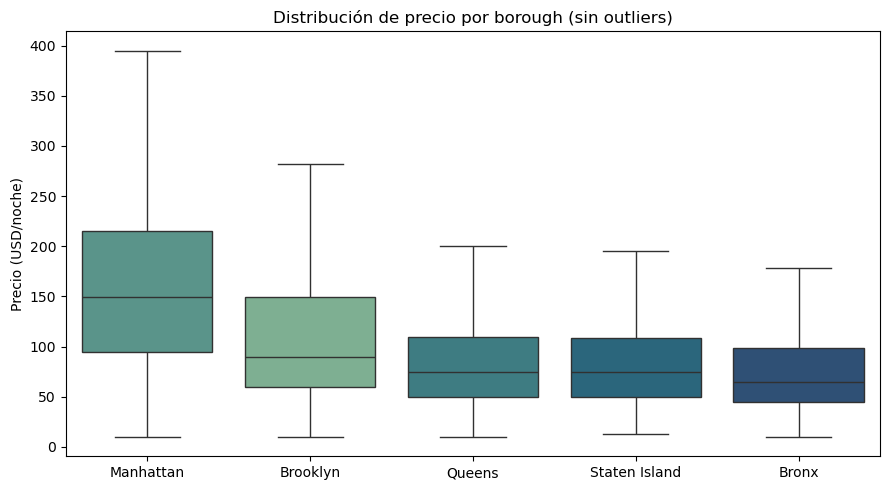

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="neighbourhood_group", y="price", hue="neighbourhood_group",
            order=order, ax=ax, palette="crest", showfliers=False, legend=False)
ax.set_title("Distribución de precio por borough (sin outliers)")
ax.set_xlabel("")
ax.set_ylabel("Precio (USD/noche)")
plt.tight_layout()
plt.show()

## Mapa geoespacial de precios

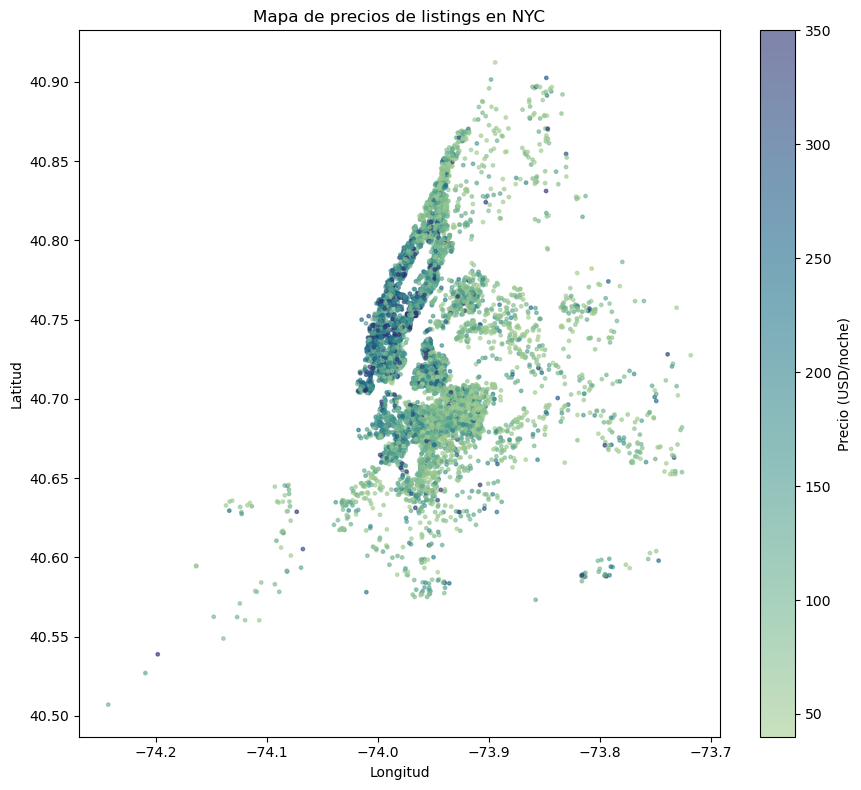

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_df = df.sample(n=min(8000, len(df)), random_state=42)
scatter = ax.scatter(
    plot_df["longitude"], plot_df["latitude"],
    c=plot_df["price"], cmap="crest", s=6, alpha=0.6,
    vmin=plot_df["price"].quantile(0.05), vmax=plot_df["price"].quantile(0.95),
)
plt.colorbar(scatter, ax=ax, label="Precio (USD/noche)")
ax.set_title("Mapa de precios de listings en NYC")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.show()

## Barrios: oferta vs. precio

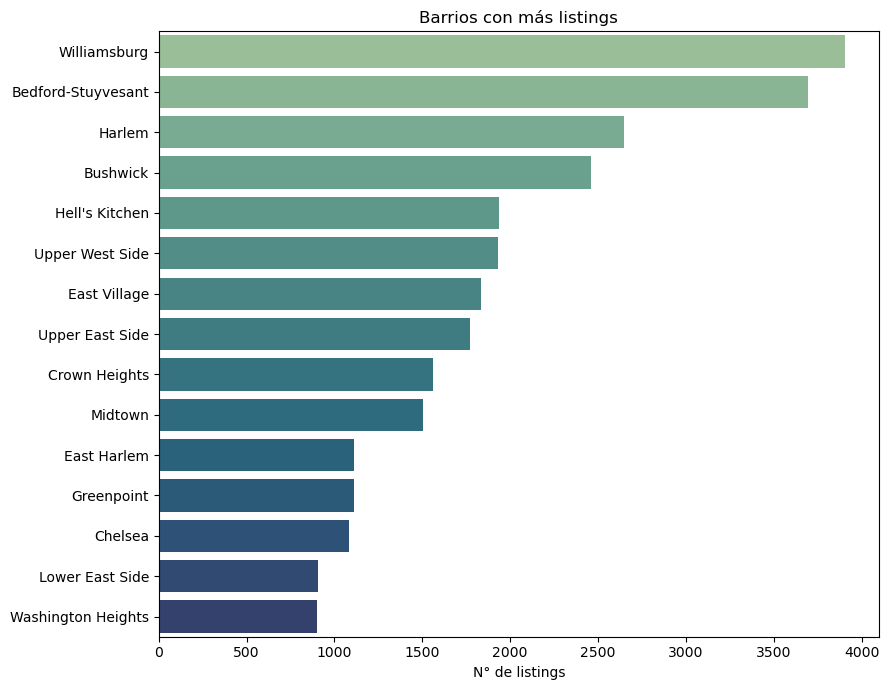


Barrios más caros (mínimo 20 listings):


,neighbourhood,avg_price,n_listings
196,Tribeca,295.65,156
143,NoHo,276.25,77
75,Flatiron District,258.16,74
126,Midtown,255.75,1503
177,SoHo,229.83,337
208,West Village,224.90,738
73,Financial District,215.75,738
190,Theater District,214.23,279
34,Chelsea,212.74,1084
136,Murray Hill,210.23,478


In [15]:
top_n = top_neighbourhoods_by_volume(df, 15)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=top_n, x="n_listings", y="neighbourhood", hue="neighbourhood",
            ax=ax, palette="crest", legend=False)
ax.set_title("Barrios con más listings")
ax.set_xlabel("N° de listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\nBarrios más caros (mínimo 20 listings):")
most_expensive_neighbourhoods(df)

## Comportamiento de hosts

In [16]:
host_rank = host_ranking_by_borough(df)
print("Top hosts por borough:")
display(host_rank.head(10))

low_engagement = superhosts_low_engagement(df)
print(f"\nHosts con 5+ listings y bajo engagement: {len(low_engagement)}")
display(low_engagement.head(10))

Top hosts por borough:


,host_id,neighbourhood_group,n_listings,rank_in_borough
949,310670,Bronx,13,1
17536,23878336,Bronx,10,2
19523,30509656,Bronx,8,3
20820,35783912,Bronx,8,3
900,295128,Bronx,7,4
5196,2988712,Bronx,7,4
32756,174785358,Bronx,7,4
37177,273354185,Bronx,7,4
19920,32164030,Bronx,6,5
12238,11305944,Bronx,5,6



Hosts con 5+ listings y bajo engagement: 181


,host_id,n_listings,avg_reviews_per_month
29147,107434423,232,0.03
19397,30283594,117,0.03
30806,137358866,103,0.22
12673,12243051,96,0.09
14296,16098958,96,0.08
25445,61391963,91,0.23
16933,22541573,87,0.05
33570,200380610,65,0.02
9650,7503643,52,0.10
3022,1475015,52,0.07


## Disponibilidad vs. precio

         room_type  avg_days_available  avg_price
0      Shared room               162.2       64.2
1  Entire home/apt               110.9      189.1
2     Private room               110.9       83.4


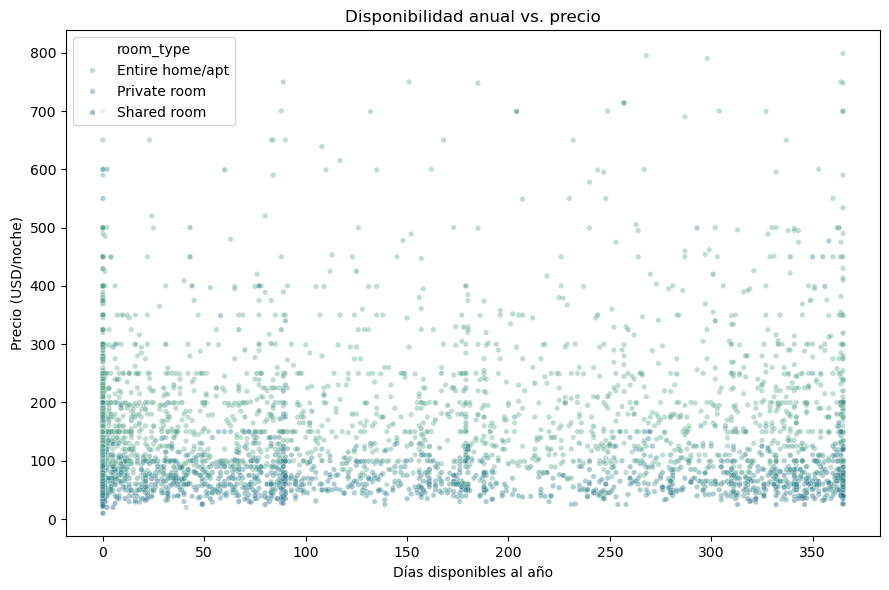

In [17]:
avail = availability_by_room_type(df)
print(avail)

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=plot_df, x="availability_365", y="price", hue="room_type",
                 alpha=0.4, s=15, ax=ax, palette="crest")
ax.set_title("Disponibilidad anual vs. precio")
ax.set_xlabel("Días disponibles al año")
ax.set_ylabel("Precio (USD/noche)")
plt.tight_layout()
plt.show()

## Conclusiones y recomendaciones
- **Manhattan** tiene el precio promedio más alto en las 3 categorías de habitación, seguido de Brooklyn.
- Los barrios con **más oferta** (Williamsburg, Bedford-Stuyvesant) no son los **más caros** (Tribeca, NoHo, Flatiron District) — dos estrategias de inversión distintas.
- Se identificaron hosts que operan 5+ listings con muy baja tasa de reseñas, una señal útil para revisión de calidad.
- El tipo de habitación ("Entire home/apt" vs. "Private room") duplica consistentemente el precio en todos los boroughs.